In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [1]:
import Stellar_sim_t_dep_analytic as SSTDA

import importlib
importlib.reload(SSTDA)

import numpy as np
import matplotlib.pyplot as plt

[CudaDevice(id=0), CudaDevice(id=1)]
[CudaDevice(id=0), CudaDevice(id=1)]


In [2]:
# [m22, r_half[Kpc], no_of_particles, no_time_steps, total_evolve_time[Gyr], r_min[pc], r_max_enclosing_frac, no_radius_bins, animate?]

animate = False

first_sim = SSTDA.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 1, no_time_steps = 1000, total_evolve_time = 5, r_min = 20, r_max_enclosing_frac = 0.99, no_radius_bins = 1000, animate=animate)


In [3]:
first_sim.run_simulation()

l max from jaxsp: 23
290 modes in the simulation
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5
  5  5  5  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  6  7  7  7  7
  7  7  7  7  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  8  8
  8  8  8  9  9  9  9  9  9  9  9  9  9  9  9  9  9 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11 11 11 11 12 12 12 12
 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 13 14 14 14 14 14
 14 14 14 14 14 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16 17 17
 17 17 17 17 17 18 18 18 18 18 18 19 19 19 19 19 20 20 20 20 21 21 21 22
 22 23]
Precomputation of Q_j_tp and R_j_r_fixed completed in 0.28 seconds


KeyboardInterrupt: 

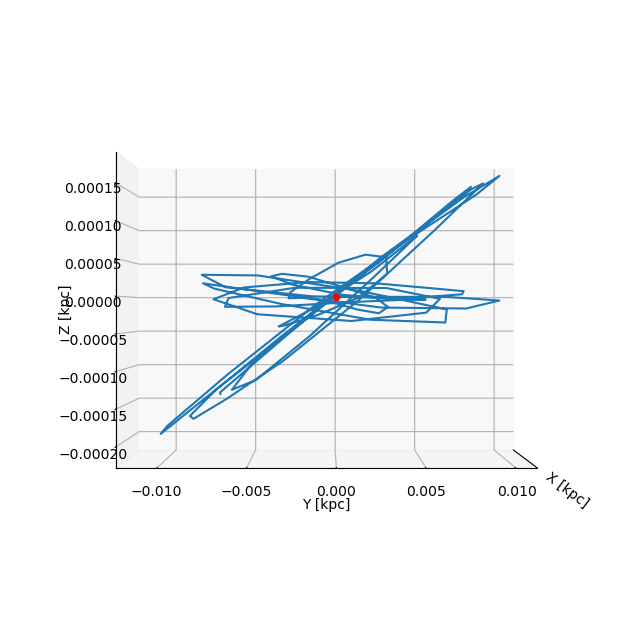

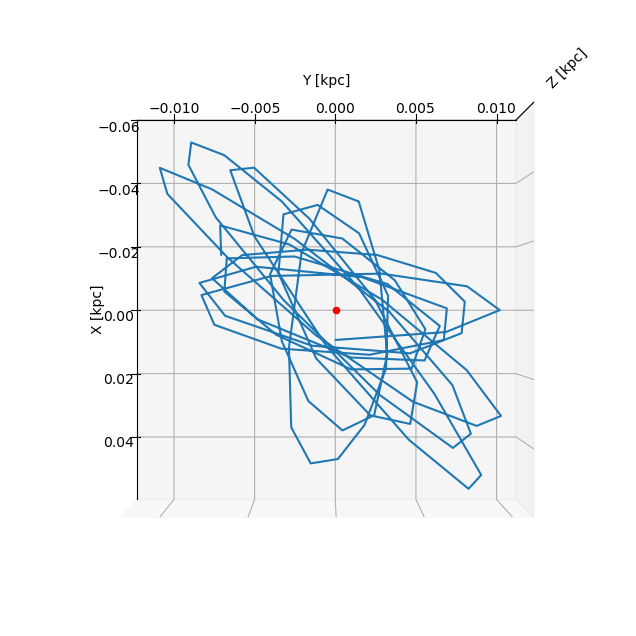

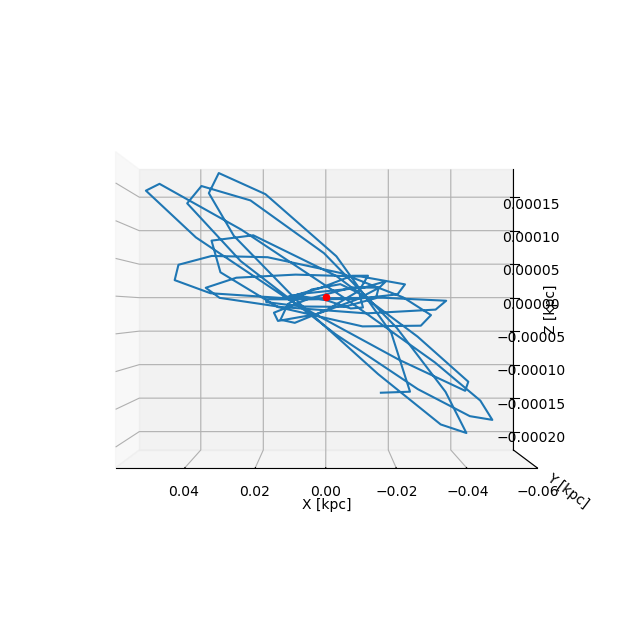

In [51]:


pos = np.array(first_sim.positions_xyz)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [ ]:
if animate == True:
    ani = first_sim.animator.create_animation()


In [52]:

velocities = np.array(first_sim.velocities)
stellar_v_disp = np.array(first_sim.stellar_v_disp) 
average_r = np.array(first_sim.average_r)
r_values = np.array(first_sim.r_values)
time_step = first_sim.time_step

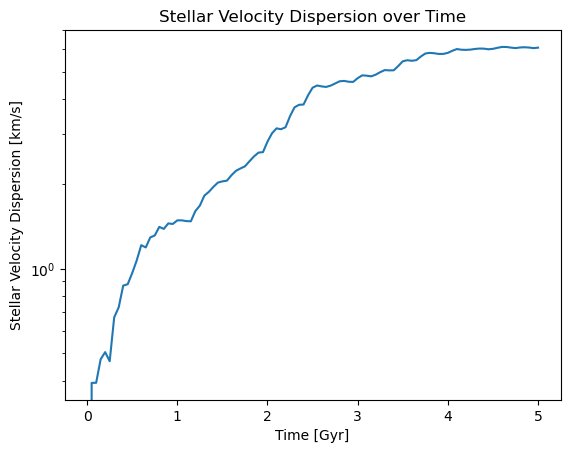

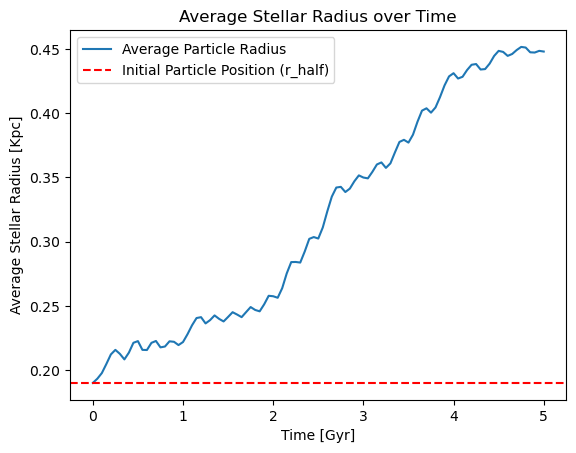

In [53]:


x = np.linspace(0, time_step, len(stellar_v_disp))

plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, stellar_v_disp * first_sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, average_r * first_sim.u.to_Kpc, label='Average Particle Radius')
#plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, r_values * first_sim.u.to_Kpc, label='Particle radial position')
plt.axhline(first_sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()

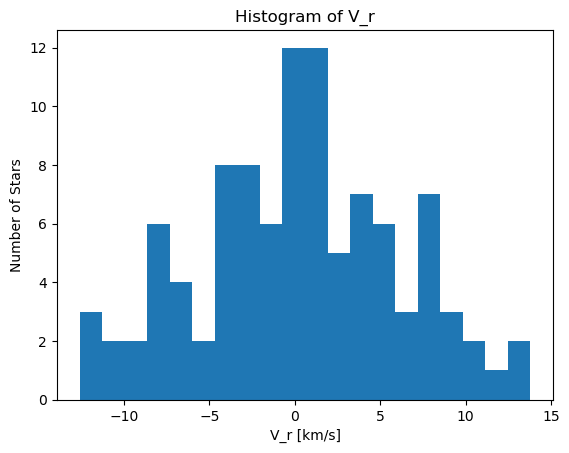

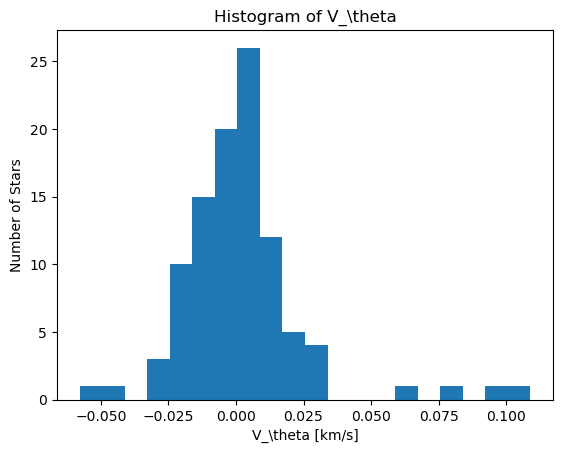

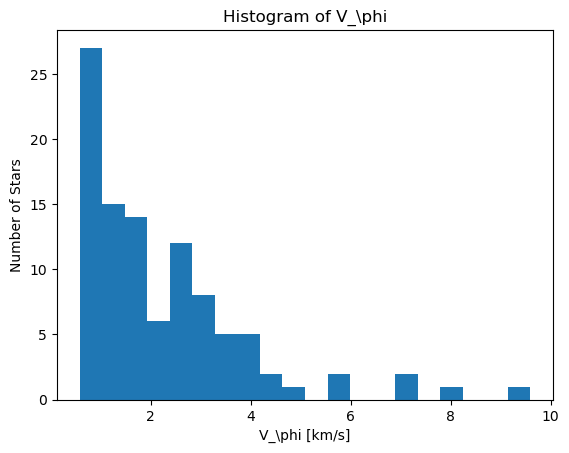

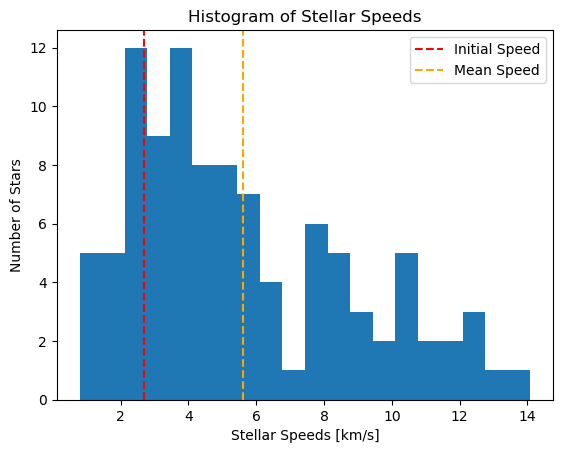

In [54]:
speeds = np.sqrt(velocities[:,0]**2 + velocities[:,1]**2 + velocities[:,2]**2)

first_speed = speeds[0]
first_vel = velocities[0]


plt.hist(velocities[:,0] * first_sim.u.to_kms, bins=20, label='Vr')
plt.xlabel(r'V_r [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_r')
plt.show()

plt.hist(velocities[:,1] * first_sim.u.to_kms, bins=20, label='Vtheta')
plt.xlabel(r'V_\theta [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_\theta')
plt.show()

plt.hist(velocities[:,2] * first_sim.u.to_kms, bins=20, label='Vphi')
plt.xlabel(r'V_\phi [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_\phi')
plt.show()

plt.hist(speeds * first_sim.u.to_kms, bins=20)
plt.axvline(first_speed * first_sim.u.to_kms, color='r', linestyle='--', label='Initial Speed')
plt.axvline(np.mean(speeds * first_sim.u.to_kms), color='orange', linestyle='--', label='Mean Speed')
plt.xlabel('Stellar Speeds [km/s]')
plt.ylabel('Number of Stars')
plt.title('Histogram of Stellar Speeds')
plt.legend()
plt.show()

In [ ]:

import Stellar_sim_t_dep_bessel as SSTDB

import importlib
importlib.reload(SSTDB)

import numpy as np 
import matplotlib.pyplot as plt

animate = False

second_sim = SSTDB.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 1, no_time_steps = 1000, total_evolve_time = 5, r_min = 20, r_max_enclosing_frac = 0.99, no_radius_bins = 1000, animate=animate)

[CudaDevice(id=0), CudaDevice(id=1)]


In [60]:
second_sim.run_simulation()



l max from jaxsp: 23
Animation enabled: density shell at r = 0.1902 kpc
Time step 2 / 1000
Constructing total psi and rho completed in 0.00 seconds
Forward s2fft completed in 0.01 seconds
Conversion from rho_lm(r) to rho_nlm completed in 0.96 seconds
0.19000066661339976
0.19000068344066326
0.19000073340484144
0.19000083233397727
0.19000098512691455
0.1900011732080967
0.19000135461211107
0.19000147823042884
0.19000068344066215
0.1900007334048485
0.19000083233397727
0.19000098512691455
0.1900011732080967
0.19000135461211107
0.19000147823042884
0.19000068344066215
0.1900007334048485
0.19000083233397727
0.19000098512691455
0.1900011732080967
0.19000135461211107
0.19000147823042884
0.19000068344066215
0.1900007334048485
0.19000083233397727
0.19000098512691455
0.1900011732080967
0.19000135461211107
0.19000147823042884
0.1900015098565295
0.19000185859920188
0.19000283323261008
0.19000465968830668
0.19000737909825935
0.19001065220263372
0.19001376732991931
0.19001587470121065
0.190001858599484

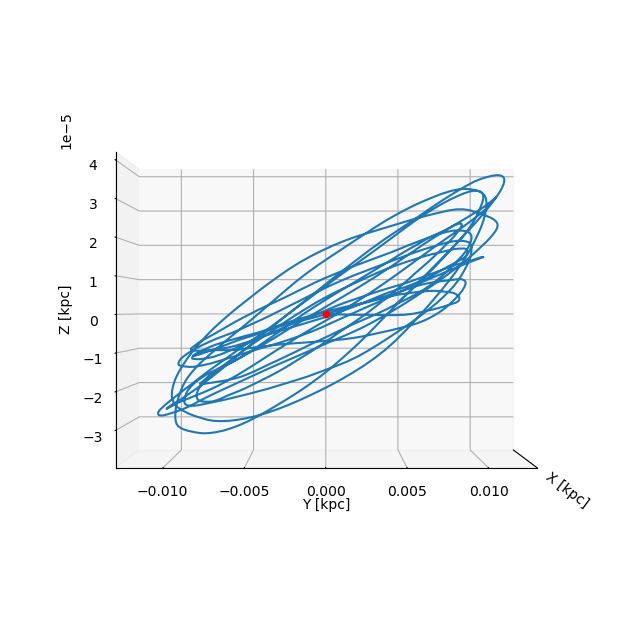

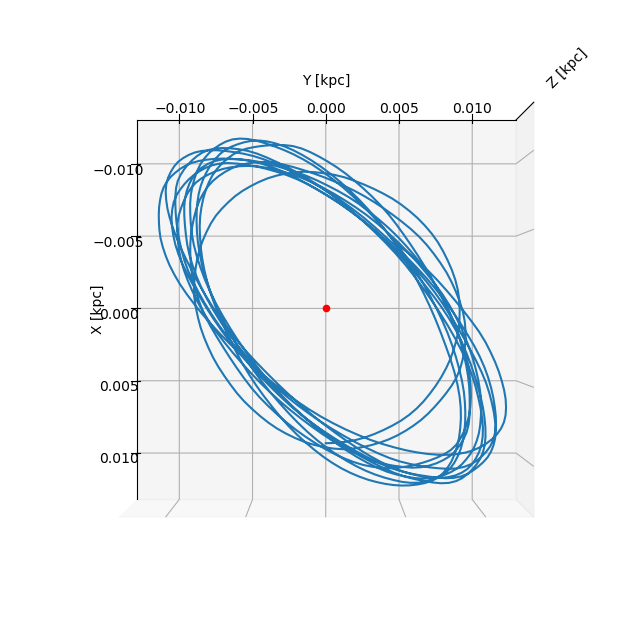

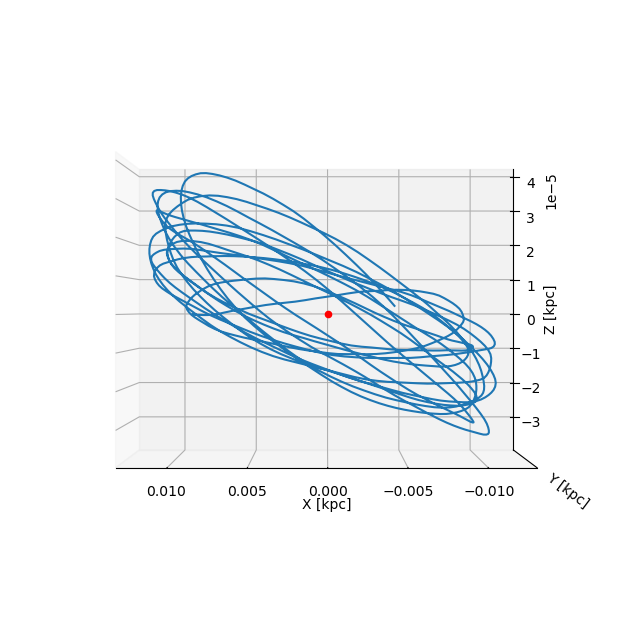

In [61]:

pos = np.array(second_sim.positions_xyz)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to /home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/stellar_simulation_20.gif


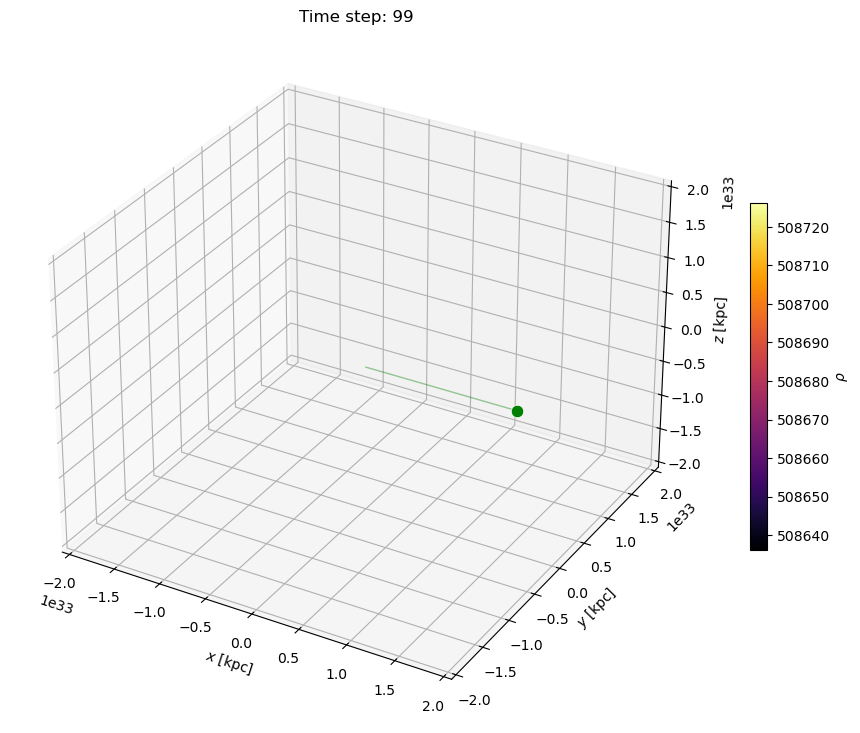

In [35]:
ani = second_sim.animator.create_animation(save_path="/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/stellar_simulation_20.gif")

In [62]:


velocities2 = np.array(second_sim.velocities)
stellar_v_disp2 = np.array(second_sim.stellar_v_disp)
average_r2 = np.array(second_sim.average_r)
r_values2= np.array(second_sim.r_values)
time_step2 = second_sim.time_step

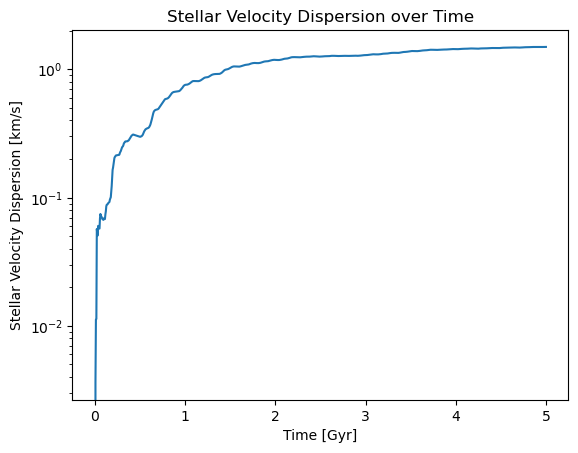

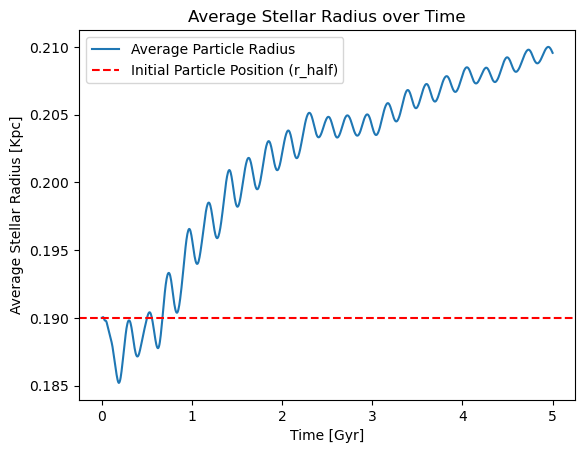

In [63]:
x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * second_sim.dt * second_sim.u.to_Gyr, stellar_v_disp2 * second_sim.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * second_sim.dt * second_sim.u.to_Gyr, average_r2 * second_sim.u.to_Kpc, label='Average Particle Radius')
#plt.plot(x * second_sim.dt * second_sim.u.to_Gyr, r_values2 * second_sim.u.to_Kpc, label='Particle radial position')
plt.axhline(second_sim.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()

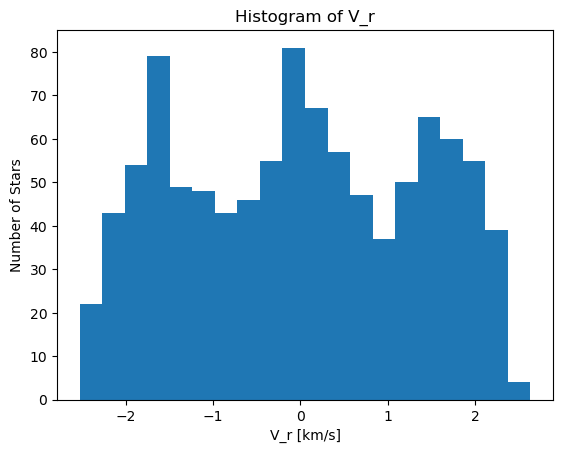

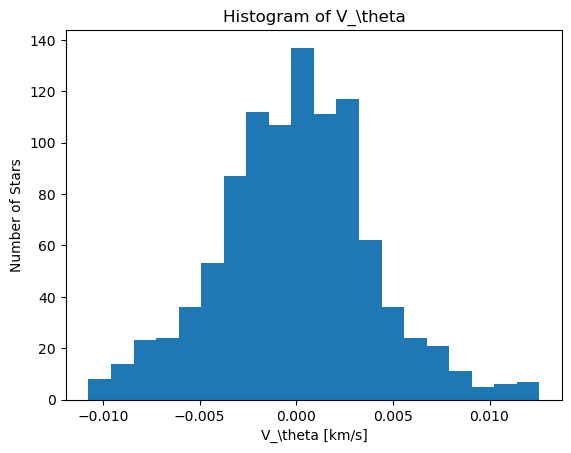

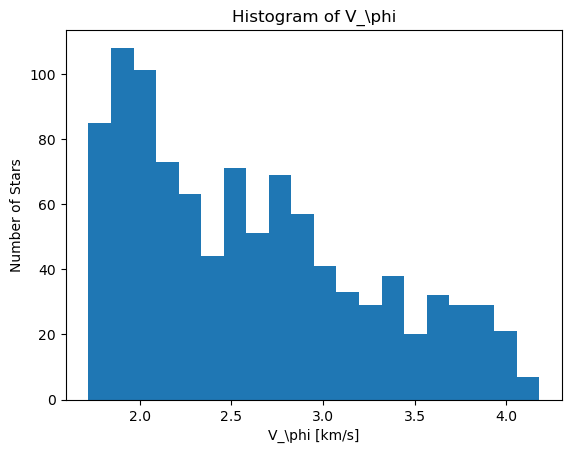

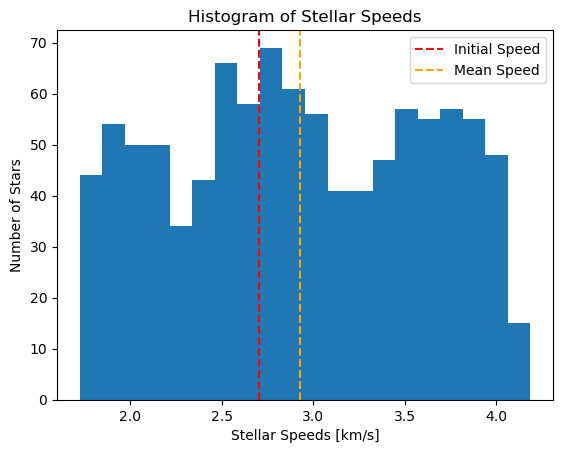

In [64]:
speeds2 = np.sqrt(velocities2[:,0]**2 + velocities2[:,1]**2 + velocities2[:,2]**2)

first_speed2 = speeds2[0]
first_vel2 = velocities2[0]


plt.hist(velocities2[:,0] * second_sim.u.to_kms, bins=20, label='Vr')
plt.xlabel(r'V_r [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_r')
plt.show()

plt.hist(velocities2[:,1] * second_sim.u.to_kms, bins=20, label='Vtheta')
plt.xlabel(r'V_\theta [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_\theta')
plt.show()

plt.hist(velocities2[:,2] * second_sim.u.to_kms, bins=20, label='Vphi')
plt.xlabel(r'V_\phi [km/s]')
plt.ylabel('Number of Stars')
plt.title(r'Histogram of V_\phi')
plt.show()

plt.hist(speeds2 * second_sim.u.to_kms, bins=20)
plt.axvline(first_speed2 * second_sim.u.to_kms, color='r', linestyle='--', label='Initial Speed')
plt.axvline(np.mean(speeds2 * second_sim.u.to_kms), color='orange', linestyle='--', label='Mean Speed')
plt.xlabel('Stellar Speeds [km/s]')
plt.ylabel('Number of Stars')
plt.title('Histogram of Stellar Speeds')
plt.legend()
plt.show()